In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
# prep the data
data = [
    {"Tracker": "BotSORT", "ReID": "osnet_x0_25", "MOTA": 96.35, "FPS": 6.68},
    {"Tracker": "HybridSORT", "ReID": "osnet_x0_25", "MOTA": 93.91, "FPS": 6.67},
    {"Tracker": "StrongSORT", "ReID": "osnet_x0_25", "MOTA": 95.56, "FPS": 4.58},

    {"Tracker": "BotSORT", "ReID": "osnet_x1_0", "MOTA": 96.13, "FPS": 7.17},
    {"Tracker": "HybridSORT", "ReID": "osnet_x1_0", "MOTA": 95.13, "FPS": 6.49},
    {"Tracker": "StrongSORT", "ReID": "osnet_x1_0", "MOTA": 95.14, "FPS": 4.58},

    {"Tracker": "BotSORT", "ReID": "resnet50", "MOTA": 96.35, "FPS": 7.53},
    {"Tracker": "HybridSORT", "ReID": "resnet50", "MOTA": 93.77, "FPS": 7.92},
    {"Tracker": "StrongSORT", "ReID": "resnet50", "MOTA": 95.14, "FPS": 2.95},

    {"Tracker": "ByteTrack", "ReID": "None (Baseline)", "MOTA": 91.86, "FPS": 13.15}
]
df = pd.DataFrame(data)

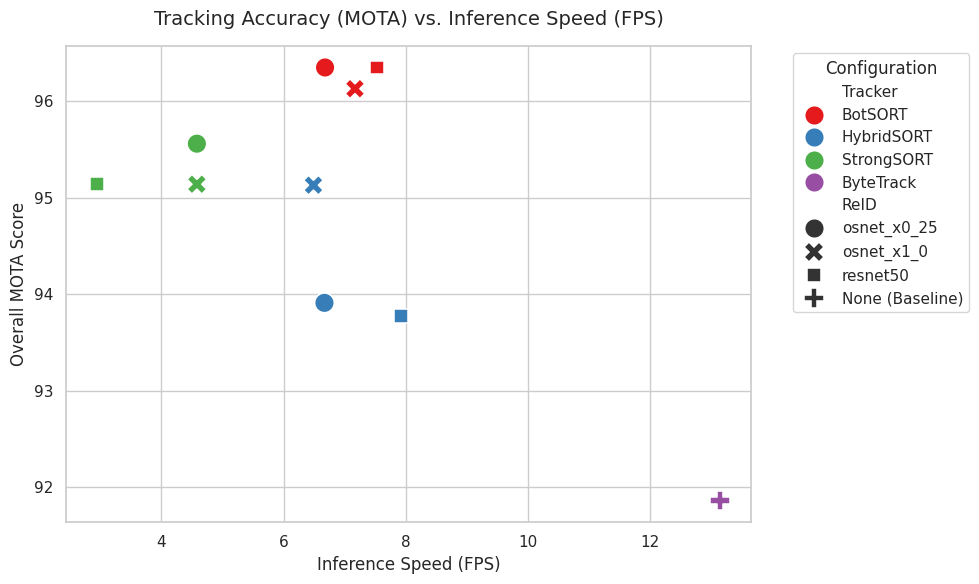

Saved: Tradeoff_Scatter.png


In [ ]:
# accuracy vs fps scatter plot
plt.figure(figsize=(10, 6))

# create the scatter plot mapping Speed (X) vs Accuracy (Y)
sns.scatterplot(
    data=df,
    x='FPS',
    y='MOTA',
    hue='Tracker',
    style='ReID',
    s=200,
    palette='Set1'
)

plt.title('Tracking Accuracy (MOTA) vs. Inference Speed (FPS)', fontsize=14, pad=15)
plt.xlabel('Inference Speed (FPS)', fontsize=12)
plt.ylabel('Overall MOTA Score', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Configuration")
plt.tight_layout()

plt.show()

plt.savefig('Tradeoff_Scatter.png', dpi=300)
plt.close()
print("Saved: Tradeoff_Scatter.png")

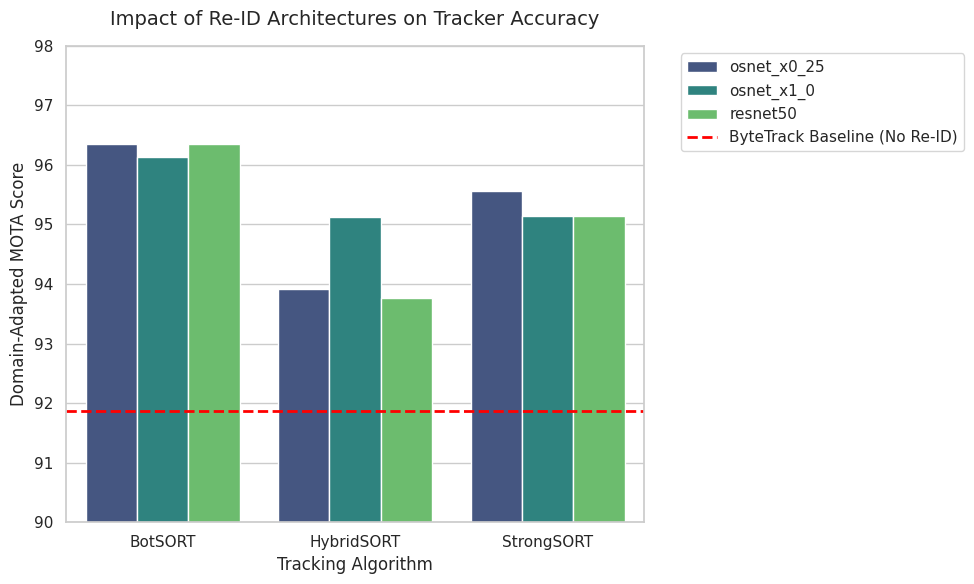

Saved: ReID_BarChart.png


In [ ]:
# overall accuracy draft
plt.figure(figsize=(10, 6))

# filter out ByteTrack so we can map it as a baseline instead of a standard bar
reid_df = df[df['Tracker'] != 'ByteTrack']

# grouped bar chart comparing trackers and their backbones
ax = sns.barplot(data=reid_df, x='Tracker', y='MOTA', hue='ReID', palette='viridis')

# ByteTrack baseline
plt.axhline(y=91.86, color='red', linestyle='--', linewidth=2, label='ByteTrack Baseline (No Re-ID)')

plt.ylim(90, 98)
plt.title('Impact of Re-ID Architectures on Tracker Accuracy', fontsize=14, pad=15)
plt.xlabel('Tracking Algorithm', fontsize=12)
plt.ylabel('Domain-Adapted MOTA Score', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.savefig('ReID_BarChart.png', dpi=300)
plt.close()
print("Saved: ReID_BarChart.png")

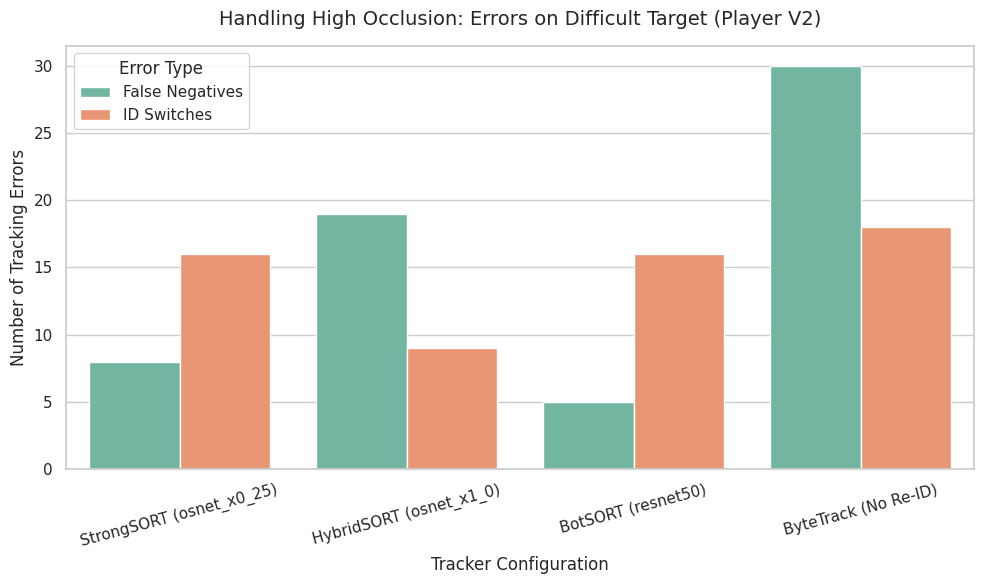

Saved: Player_V2_Errors.png


In [ ]:
# player 2 analysis

v2_data = [
    {"Tracker Configuration": "StrongSORT (osnet_x0_25)", "False Negatives": 8, "ID Switches": 16},
    {"Tracker Configuration": "HybridSORT (osnet_x1_0)", "False Negatives": 19, "ID Switches": 9},
    {"Tracker Configuration": "BotSORT (resnet50)", "False Negatives": 5, "ID Switches": 16},
    {"Tracker Configuration": "ByteTrack (No Re-ID)", "False Negatives": 30, "ID Switches": 18}
]
df_v2 = pd.DataFrame(v2_data)

df_v2_melted = df_v2.melt(id_vars='Tracker Configuration', var_name='Error Type', value_name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_v2_melted, x='Tracker Configuration', y='Count', hue='Error Type', palette='Set2')

plt.title('Handling High Occlusion: Errors on Difficult Target (Player V2)', fontsize=14, pad=15)
plt.xlabel('Tracker Configuration', fontsize=12)
plt.ylabel('Number of Tracking Errors', fontsize=12)

plt.xticks(rotation=15)
plt.legend(title='Error Type')
plt.tight_layout()
plt.show()
plt.savefig('Player_V2_Errors.png', dpi=300)
plt.close()
print("Saved: Player_V2_Errors.png")